In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
tickers=['AAPL','MSFT','NVDA','TSLA','GOOGL']
data=yf.download(
    tickers,
    start='2020-01-01',
    auto_adjust=True,
    progress=False
)['Close']
data=data.dropna()

In [6]:
print(data.head())

Ticker           AAPL      GOOGL        MSFT      NVDA       TSLA
Date                                                             
2020-01-02  72.333878  67.832504  151.829529  5.963804  28.684000
2020-01-03  71.630630  67.477646  149.938995  5.868347  29.534000
2020-01-06  72.201424  69.276207  150.326569  5.892956  30.102667
2020-01-07  71.861847  69.142395  148.955917  5.964302  31.270666
2020-01-08  73.017830  69.634529  151.328552  5.975487  32.809334


In [9]:
returns=data.pct_change().dropna()
print(returns.head())

Ticker          AAPL     GOOGL      MSFT      NVDA      TSLA
Date                                                        
2020-01-03 -0.009722 -0.005231 -0.012452 -0.016006  0.029633
2020-01-06  0.007969  0.026654  0.002585  0.004194  0.019255
2020-01-07 -0.004703 -0.001932 -0.009118  0.012107  0.038801
2020-01-08  0.016086  0.007118  0.015928  0.001875  0.049205
2020-01-09  0.021241  0.010498  0.012493  0.010983 -0.021945


In [11]:
annual_return=returns.mean()*252
annual_volatility=returns.std()*(252**0.5)
print('Annual Return:')
print(annual_return.sort_values(ascending=False))
print('\nannual_volatility:')
print(annual_volatility.sort_values(ascending=False))

Annual Return:
Ticker
NVDA     0.675043
TSLA     0.616792
GOOGL    0.307189
AAPL     0.259693
MSFT     0.183716
dtype: float64

annual_volatility:
Ticker
TSLA     0.650044
NVDA     0.522109
GOOGL    0.323930
AAPL     0.313942
MSFT     0.299270
dtype: float64


In [15]:
sharpe_ratio=annual_return/annual_volatility
print('sharpe_ratio')
print(sharp_ratio.sort_values(ascending=False))

sharpe_ratio
Ticker
NVDA     1.292916
TSLA     0.948846
GOOGL    0.948320
AAPL     0.827202
MSFT     0.613880
dtype: float64


In [23]:
cumulative=(1+returns).cumprod()
running_max=cummlative.cummax()
drawdown=cummlative/running_max
max_drawdown=drawdown.min()
print('Max Drawdown:')
print(max_drawdown)

Max Drawdown:
Ticker
AAPL     0.666395
GOOGL    0.556799
MSFT     0.628515
NVDA     0.336649
TSLA     0.263678
dtype: float64


In [24]:
metrics=pd.DataFrame({
    "Annual Return":annual_return,
    "Annual Volatility":annual_volatility,
    "Sharpe Ratio":sharpe_ratio,
    "Max DrawDown":max_drawdown
})
metrics=metrics.sort_values("Sharpe Ratio",ascending=False)
print(metrics)

        Annual Return  Annual Volatility  Sharpe Ratio  Max DrawDown
Ticker                                                              
NVDA         0.675043           0.522109      1.292916      0.336649
TSLA         0.616792           0.650044      0.948846      0.263678
GOOGL        0.307189           0.323930      0.948320      0.556799
AAPL         0.259693           0.313942      0.827202      0.666395
MSFT         0.183716           0.299270      0.613880      0.628515


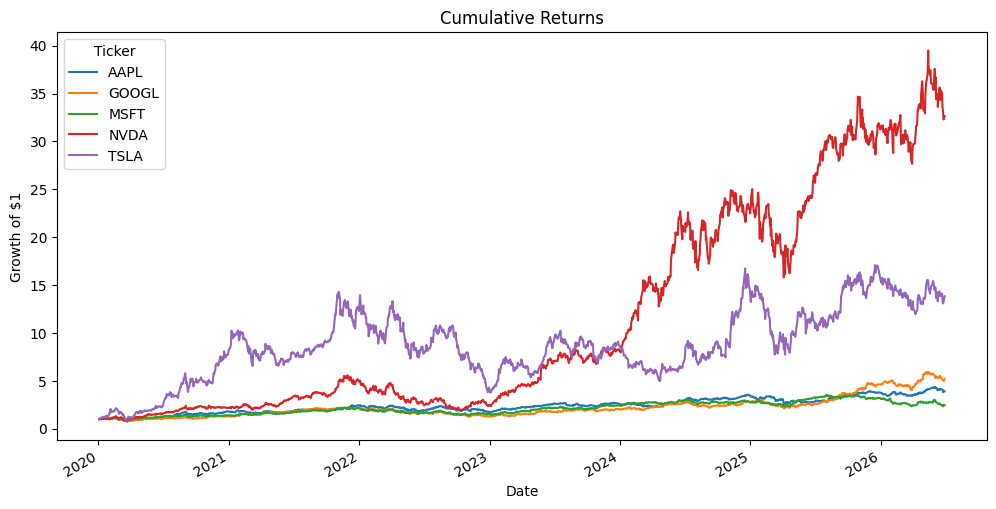

In [26]:
cumulative.plot(figsize=(12, 6), title="Cumulative Returns")
plt.ylabel("Growth of $1")
plt.show()

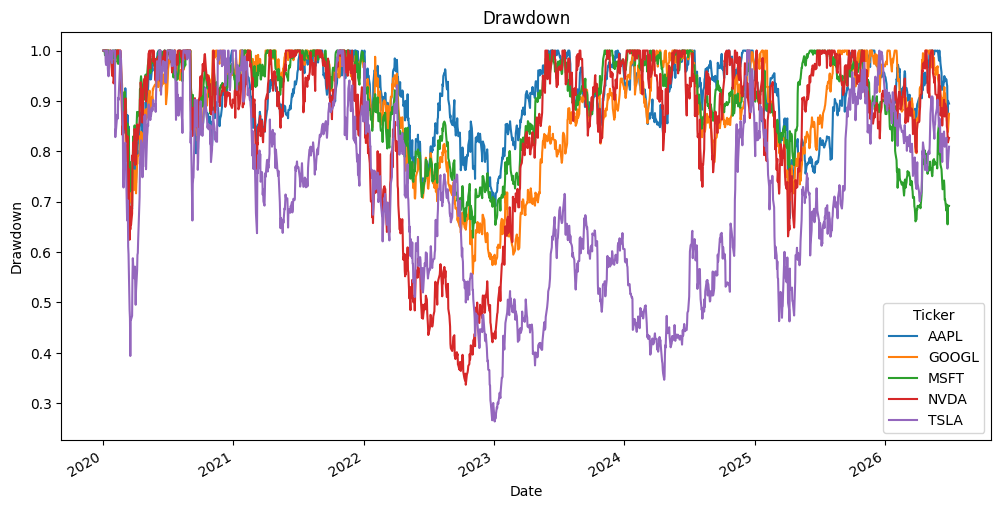

In [27]:
drawdown.plot(figsize=(12, 6), title="Drawdown")
plt.ylabel("Drawdown")
plt.show()